# SVM From Scratch.

---

In [1]:
import time

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
data = pd.read_csv("preprocessed_cell_diagnosis_svm.csv")

## Train-Test-Split:

In [3]:
X = data.drop(columns=['Diagnosis'])
y = data['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Building Model From Scratch:

In [5]:
class SVM:

    def __init__(self, learning_rate, max_iter, C, kernel):

        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.C = C
        self.kernel = kernel
        self.weights = None
        self.intercept = None
        self.loss = []

    def fit(self, X_train, y_train):

        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)
        self.y_train = np.where(self.y_train == 0, -1, 1)

        if(self.kernel == 'linear'):

            self.weights = np.zeros(X_train.shape[1])
            self.intercept = 0
    
            for epoch in range(self.max_iter):
    
                for i in range(self.X_train.shape[0]):
    
                    if(self.y_train[i] * (np.dot(self.weights, self.X_train[i]) + self.intercept) >= 1):

                        slope_w = self.weights
                        slope_b = 0

                    else:

                        slope_w = self.weights - self.C * (self.y_train[i] * self.X_train[i])
                        slope_b = -(self.C * self.y_train[i])

                    self.weights = self.weights - (self.learning_rate * slope_w)
                    self.intercept = self.intercept - (self.learning_rate * slope_b)

                loss = (1/2 * np.sum(self.weights**2)) + (self.C * (np.maximum(0, 1 - self.y_train[i] * (np.dot(self.weights, self.X_train[i]) + self.intercept))))
                self.loss.append(loss)

    def predict(self, X_test):

        predictions = np.dot(X_test, self.weights) + self.intercept
        
        return np.where(predictions > 0 , 1, 0)

In [6]:
svm = SVM(learning_rate=0.01, max_iter=10, C=0.1, kernel='linear')

start_time = time.time()
svm.fit(X_train, y_train)
end_time = time.time() - start_time

print("Model Trained Successfully!")
print(f"Time Taken for Training: {end_time:.2f}s")  

Model Trained Successfully!
Time Taken for Training: 0.19s


## Results:

In [7]:
y_pred = svm.predict(X_test)

print(f"Accuracy: {(accuracy_score(y_test, y_pred)*100):.2f}%")

print(f"\nPrecision: {(precision_score(y_test, y_pred)*100):.2f}%")

print(f"\nRecall: {(recall_score(y_test, y_pred)*100):.2f}%")

print(f"\nF1 Score: {(f1_score(y_test, y_pred)*100):.2f}%")

print("\n")
matrix = confusion_matrix(y_test, y_pred)
matrix_df = pd.DataFrame(matrix, index=['Actual Benign', 'Actual Maligant'], columns=['Predicted Benign', 'Predicted Maligant'])
matrix_df

Accuracy: 97.13%

Precision: 100.00%

Recall: 94.44%

F1 Score: 97.14%




,Predicted Benign,Predicted Maligant
Actual Benign,118,0
Actual Maligant,7,119


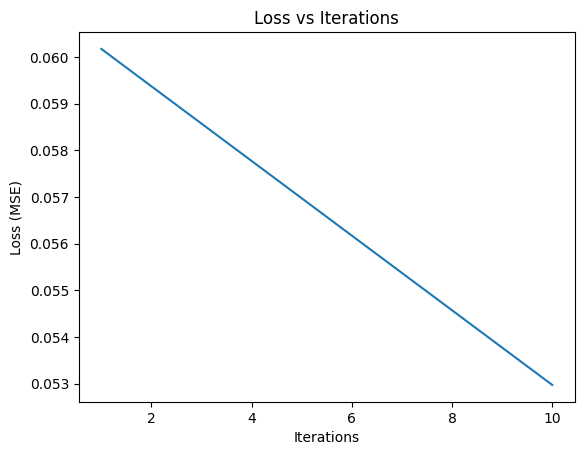

In [8]:
plt.plot(range(1, len(svm.loss) + 1), svm.loss)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Iterations")
plt.show()